# 📊 Global Layoffs Analysis & Pandas vs Polars Benchmark


## 🧠 Overview
This project analyzes global tech layoffs to uncover key trends across countries, companies, industries, and time.

In addition, it explores a key technical question:
> Is Polars always faster than Pandas?

---

## 🎯 Objectives
- Clean and analyze layoffs data  
- Identify major patterns and extreme cases  
- Visualize trends over time and across regions  
- Compare performance between Pandas and Polars  

---

## ⚡ Key Insight
Performance depends on data size:
- Pandas works efficiently for smaller datasets  
- Polars shows advantages with larger-scale data  

---

## 🛠️ Tools
Python, Pandas, Polars, Matplotlib / Plotly  




In [2]:
pip install pandas polars matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 824.0/824.0 kB 2.9 MB/s eta 0:00:00-:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 7.7 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [7]:
df_pd.head()
df_pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1745 entries, 0 to 1744
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Nr                           1745 non-null   int64  
 1   Company                      1745 non-null   object 
 2   Location_HQ                  1745 non-null   object 
 3   Region                       1745 non-null   object 
 4   USState                      1744 non-null   object 
 5   Country                      1745 non-null   object 
 6   Continent                    1745 non-null   object 
 7   Laid_Off                     1745 non-null   float64
 8   Date_layoffs                 1745 non-null   object 
 9   Percentage                   1745 non-null   float64
 10  Company_Size_before_Layoffs  1745 non-null   float64
 11  Company_Size_after_layoffs   1745 non-null   float64
 12  Industry                     1745 non-null   object 
 13  Stage             

In [15]:
# Clean column names (remove spaces & make lowercase)
df_pd.columns = df_pd.columns.str.strip().str.lower()

In [11]:
# Check column names after cleaning
(df_pd.columns)

Index(['Nr', 'Company', 'Location_HQ', 'Region', 'USState', 'Country',
       'Continent', 'Laid_Off', 'Date_layoffs', 'Percentage',
       'Company_Size_before_Layoffs', 'Company_Size_after_layoffs', 'Industry',
       'Stage', 'Money_Raised_in__mil', 'Year', 'latitude', 'longitude'],
      dtype='object')


In [ ]:
# Remove rows with missing layoffs data
df_pd = df_pd.dropna(subset=["laid_off"])

In [21]:
# Total layoffs by country (sorted descending)
df_pd.groupby("country")["laid_off"].sum().sort_values(ascending=False)

country
USA                        425063.0
India                       41492.0
Germany                     25809.0
Sweden                      17057.0
UK                          13409.0
Israel                      11985.0
Canada                      10815.0
Brazil                       7029.0
Singapore                    5187.0
Japan                        5120.0
Indonesia                    2721.0
Australia                    2664.0
Nigeria                      1140.0
United Arabian Emirates      1088.0
France                       1040.0
Netherlands                  1030.0
New Zealand                  1025.0
Kenya                         982.0
China                         755.0
Hong Kong                     730.0
Ireland                       456.0
United Kingdom                440.0
Denmark                       414.0
Russia                        400.0
Argentina                     373.0
Estonia                       373.0
South Korea                   350.0
Spain               

In [23]:
# Standardize country names for consistency
["country"] = df_pd["country"].replace({
    "UK": "United Kingdom",
    "United Arabian Emirates": "United Arab Emirates"
})

In [27]:
# Identify companies with 100% layoffs and significant impact
df_pd[
    (df_pd["percentage"] == 100) & (df_pd["laid_off"] > 100)
][["company", "percentage", "laid_off"]].sort_values(by="laid_off", ascending=False)

,company,percentage,laid_off
1723,Amdocs,100.0,4500.0
339,Katerra,100.0,2434.0
1649,Lilium,100.0,1000.0
552,Butler Hospitality,100.0,1000.0
1579,Redbox,100.0,1000.0
1245,Bitwise,100.0,900.0
1383,Zulily,100.0,839.0
244,Deliv,100.0,669.0
1612,Eaze,100.0,500.0
234,Jump,100.0,500.0


In [29]:
# Calculate workforce reduction per company
# Top companies by total workforce reduction
df_pd["size_reduction"] = df_pd["company_size_before_layoffs"] - df_pd["company_size_after_layoffs"]

df_pd.groupby("company")["size_reduction"].sum().sort_values(ascending=False).head(10)

company
Intel                             37022.0
Amazon                            27150.0
Microsoft                         25305.0
Meta                              24600.0
Tesla                             14000.0
Cisco                             13950.0
Google                            12000.0
TCS                               12000.0
SAP                               11000.0
SaleSan Francisco Bay Areaorce    10000.0
Name: size_reduction, dtype: float64

<Axes: title={'center': 'Top Companies by Workforce Reduction'}, xlabel='company'>

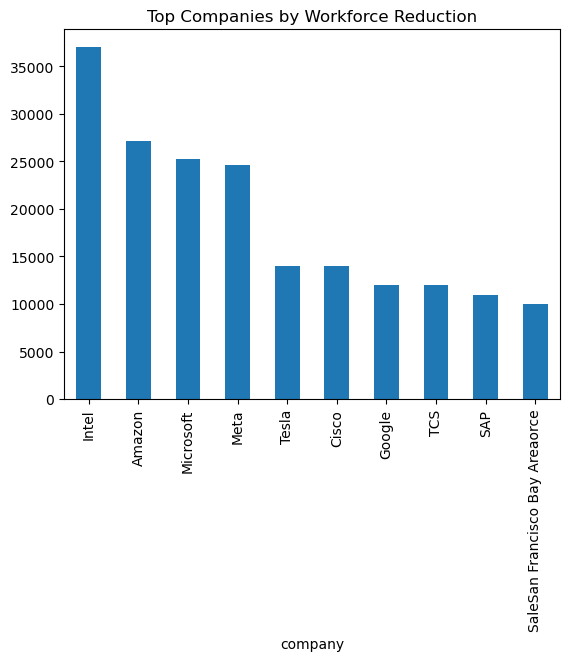

In [41]:
# Visualize top companies by workforce reduction
df_pd.groupby("company")["size_reduction"]\
.sum().sort_values(ascending=False).head(10)\
.plot(kind="bar", title="Top Companies by Workforce Reduction")

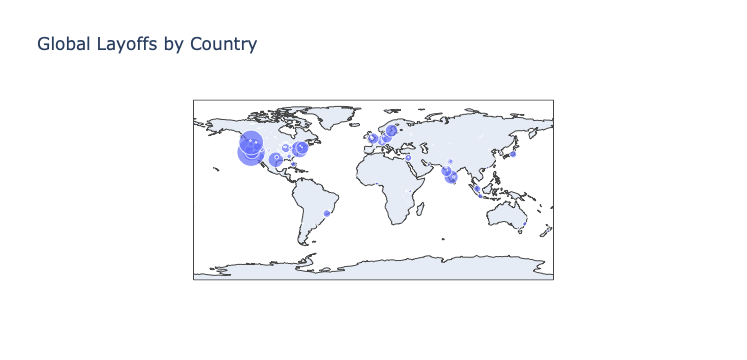

In [43]:
# Aggregate layoffs by country and location (lat, lon)
# Visualize global layoffs distribution on a map
df_map = df_pd.groupby(["country", "latitude", "longitude"])["laid_off"].sum().reset_index()

fig = px.scatter_geo(
    df_map,
    lat="latitude",
    lon="longitude",
    size="laid_off",
    hover_name="country",
    title="Global Layoffs by Country"
)

fig.show()
# Insight: Layoffs are concentrated in major economic and tech hubs, especially in the US and Europe$

In [33]:
# Analyze layoffs distribution across industries (Top 10)
df_pd.groupby("industry")["laid_off"]\
.sum().sort_values(ascending=False).head(10)

industry
Consumer                61155.0
Retail                  59228.0
Hardware                57000.0
Other                   56721.0
Transportation          39046.0
Finance                 36185.0
Food                    33702.0
Software Development    17115.0
Infrastructure          16798.0
Healthcare              16109.0
Name: laid_off, dtype: float64

<Axes: title={'center': 'Global Layoffs Trend Over Time'}, xlabel='Date', ylabel='Number of Layoffs'>

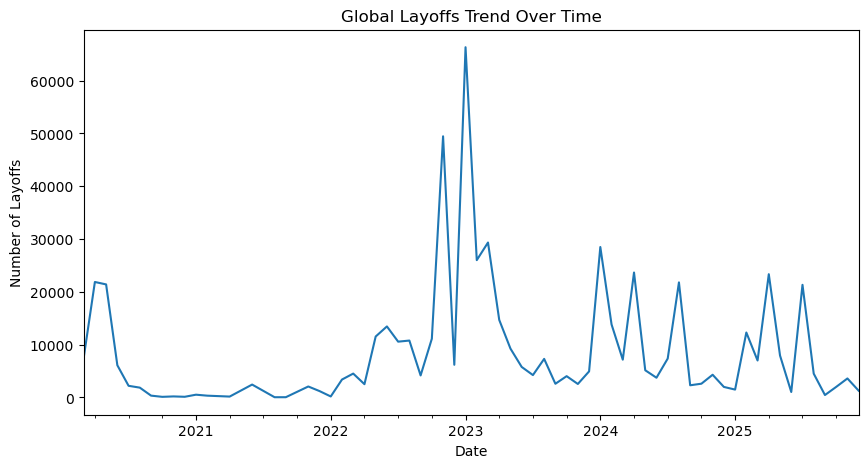

In [45]:
# Analyze layoffs trend over time (monthly aggregation)
df_pd.groupby(df_pd["date_layoffs"].dt.to_period("M"))["laid_off"]\
.sum().plot(
    figsize=(10,5),
    title="Global Layoffs Trend Over Time",
    xlabel="Date",
    ylabel="Number of Layoffs"
)

In [49]:
# Top companies by average funding raised
df_pd.groupby("company")["money_raised_in__mil"]\
.mean().sort_values(ascending=False).head(10)

company
Netflix          121900.000000
Meta              26000.000000
Uber              24825.000000
WeWork            19500.000000
Grab              16500.000000
Twitter           12900.000000
Cruise            11766.666667
Rivian            10700.000000
Lucid Motors       8300.000000
Delivery Hero      8300.000000
Name: money_raised_in__mil, dtype: float64

## ⚡ Performance Comparison: Pandas vs Polars

In [5]:
# Pandas
start = time.time()
df_pd = pd.read_csv("Cleaned_tech_layoffs.csv")
print("Pandas read time:", time.time() - start)

# Polars
start = time.time()
df_pl = pl.read_csv("Cleaned_tech_layoffs.csv")
print("Polars read time:", time.time() - start)

Pandas read time: 0.011597871780395508
Polars read time: 0.08981204032897949


In [56]:
df_pl.columns = [col.strip().lower() for col in df_pl.columns]

In [58]:
# Pandas
start = time.time()
df_pd.groupby("country")["laid_off"].sum()
end = time.time()
print("Pandas GroupBy Time:", end - start)

# Polars
start = time.time()
df_pl.group_by("country").agg(pl.col("laid_off").sum())
end = time.time()
print("Polars GroupBy Time:", end - start)

Pandas GroupBy Time: 0.001986980438232422
Polars GroupBy Time: 0.006764650344848633


In [60]:
# Pandas
start = time.time()
df_pd[df_pd["laid_off"] > 100]
end = time.time()
print("Pandas Filter Time:", end - start)

# Polars
start = time.time()
df_pl.filter(pl.col("laid_off") > 100)
end = time.time()
print("Polars Filter Time:", end - start)

Pandas Filter Time: 0.002444028854370117
Polars Filter Time: 0.0023679733276367188


In [62]:
# Pandas
start = time.time()
df_pd["size_reduction"] = df_pd["company_size_before_layoffs"] - df_pd["company_size_after_layoffs"]
end = time.time()
print("Pandas Calculation Time:", end - start)

# Polars
start = time.time()
df_pl = df_pl.with_columns(
    (pl.col("company_size_before_layoffs") - pl.col("company_size_after_layoffs")).alias("size_reduction")
)
end = time.time()
print("Polars Calculation Time:", end - start)

Pandas Calculation Time: 0.0007221698760986328
Polars Calculation Time: 0.003183126449584961




# Pandas🐼 performed faster in this case due to small dataset size.
# Polars⚡ is expected to outperform Pandas on larger datasets.